In [21]:
def estimate_parameters(delta, rho_matrix, ternary=True, track=False):
    rho_matrix = np.asarray(rho_matrix)
    delta = np.asarray(delta)

    beta_obs = (delta != 0).mean()
    lambda_param = 1.0
    if beta_obs == 0:
        return 0.0  # no changes observed → no embedding
    history = []
    for _ in range(75):
        exponent = np.exp(-lambda_param * rho_matrix)
        if ternary:
            p_i = exponent / (1 + 2 * exponent)
            beta_theo = np.mean(2 * p_i)
        else:
            p_i = exponent / (1 + exponent)
            beta_theo = np.mean(p_i)

        if track:
            history.append(lambda_param)

        if abs(beta_theo - beta_obs) < 1e-6:
            break
        lambda_param *= (beta_theo / beta_obs) ** 0.5

    if track:
        return lambda_param, history
    return lambda_param

In [22]:
import numpy as np
import os


def load_img(name, perc, method):
    if method == "cover":
        base_path = "../../data/boss_cover/"
    else:
        base_path = "../data/" + method + "/" + str(round(perc * 100))

    img_path = os.path.join(base_path, str(name) + ".png")

    with Image.open(img_path) as img:

        image_array = np.array(img.convert("L"))
    return image_array

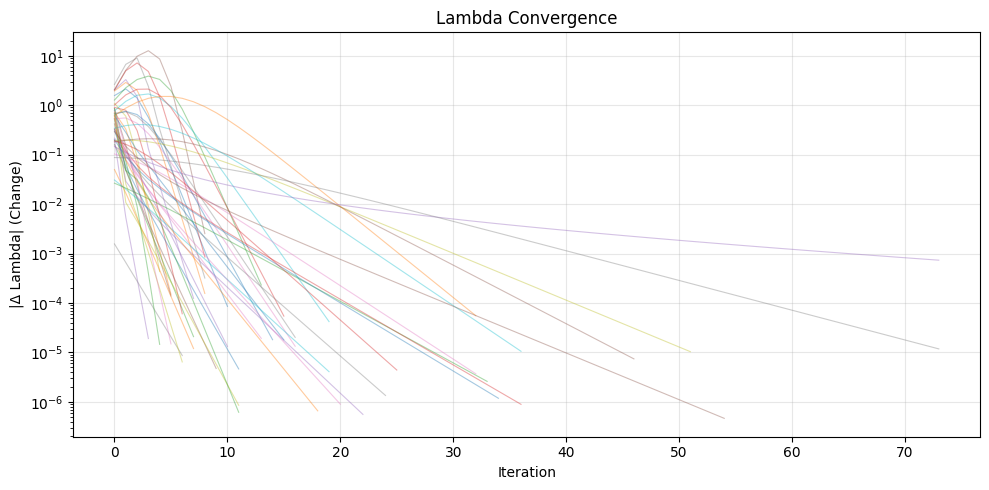

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import conseal as cl

delta_arr_dict = {}
rho_dict = {}

methods_spatial = {
    "hill": cl.hill.compute_cost_adjusted,
    "hugo": cl.hugo.compute_cost_adjusted,
    "suniward": cl.suniward.compute_cost_adjusted,
    "wow": cl.wow.compute_cost_adjusted,
}

fig, ax1 = plt.subplots(figsize=(10, 5))


all_changes = []

for alpha in [0.2, 0.5, 0.9]:
    for image_id in [1, 100, 1001, 1002]:
        for method_name, cost_fn in methods_spatial.items():
            cover = load_img(str(image_id), alpha, "cover")
            stego = load_img(str(image_id), alpha, method_name)
            delta = stego.astype(np.int16) - cover.astype(np.int16)
            delta_arr = np.asarray(
                delta[:, :, 0] if delta.ndim == 3 else delta, dtype=np.float64
            )

            rho_raw = np.asarray(cost_fn(cover), dtype=np.float64)
            rho = rho_raw[0]

            lam, history = estimate_parameters(
                delta_arr, rho, ternary=True, track=True
            )
            changes = np.abs(np.diff(history))
            all_changes.append(changes)
            if len(history) == 100:  # nicht konvergiert
                print(
                    f"NICHT KONVERGIERT: {method_name} alpha={alpha} image={image_id}, lambda={lam:.4f}"
                )
            ax1.plot(changes, alpha=0.4, linewidth=0.8)
            ax2.plot(changes, alpha=0.4, linewidth=0.8)  # erste 10 Iterationen

ax1.set_xlabel("Iteration")
ax1.set_ylabel("|Δ Lambda| (Change)")
ax1.set_title("Lambda Convergence")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("lambda_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

/home/feierabe/venv_info_projekt/lib/python3.12/site-packages/conseal/ebs/_costmap.py:78: RuntimeWarning: divide by zero encountered in divide
  block_distortion = 1/(block_entropies**theta)


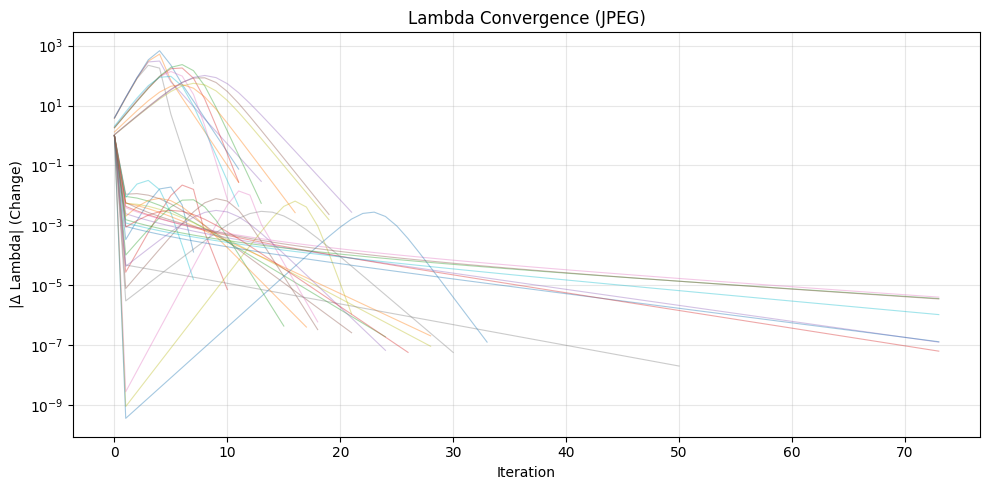

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import conseal as cl
import jpeglib
from pathlib import Path

data_dir = Path("/home/feierabe/info_hiding_data/stegos/data/jpeg")


def load_jpeg(image_id, alpha_dir_name, method):
    alpha_pct = int(float(alpha_dir_name) * 100)
    if method == "cover":
        path = data_dir / "cover" / f"{image_id}.jpg"
    else:
        path = data_dir / method / alpha_dir_name / f"{image_id}.jpg"

    dct_j = jpeglib.read_dct(str(path))
    spatial_j = jpeglib.read_spatial(str(path))
    return dct_j.Y, spatial_j.spatial[:, :, 0], dct_j.qt[0]


fig, ax1 = plt.subplots(figsize=(10, 5))

for alpha in [0.2, 0.5, 0.9]:
    for image_id in [1, 100, 1001, 1002]:
        cover_dct, cover_spatial, qtable = load_jpeg(
            str(image_id), str(int(alpha * 100)), "cover"
        )

        cost_functions = {
            "juniward": lambda: cl.juniward.compute_cost_adjusted(
                x0=cover_spatial, y0=cover_dct, qt=qtable
            ),
            "uerd": lambda: cl.uerd.compute_cost_adjusted(
                y0=cover_dct, qt=qtable
            ),
            "ebs": lambda: cl.ebs.compute_cost_adjusted(
                y0=cover_dct, qt=qtable
            ),
        }

        embed_mask_f5 = cover_dct != 0
        embed_mask_f5[:, :, 0, 0] = False

        stego_dct, _, _ = load_jpeg(
            str(image_id), str(int(alpha * 100)), "juniward"
        )  # placeholder
        delta = (
            stego_dct.astype(np.int32) - cover_dct.astype(np.int32)
        ).astype(np.float64)

        for method_name, cost_fn in cost_functions.items():
            stego_dct, _, _ = load_jpeg(
                str(image_id), str(int(alpha * 100)), method_name
            )
            delta = (
                stego_dct.astype(np.int32) - cover_dct.astype(np.int32)
            ).astype(np.float64)

            rho_raw = np.asarray(cost_fn(), dtype=np.float64)
            rho = rho_raw[0] if rho_raw.ndim == 5 else rho_raw

            delta_fit = delta[embed_mask_f5]
            rho_fit = rho[embed_mask_f5]

            lam, history = estimate_parameters(
                delta_fit, rho_fit, ternary=True, track=True
            )
            changes = np.abs(np.diff(history))

            if len(history) == 50:
                print(
                    f"NICHT KONVERGIERT: {method_name} alpha={alpha} image={image_id}, lambda={lam:.4f}"
                )

            ax1.plot(changes, alpha=0.4, linewidth=0.8)

ax1.set_xlabel("Iteration")
ax1.set_ylabel("|Δ Lambda| (Change)")
ax1.set_title("Lambda Convergence (JPEG)")
ax1.set_yscale("log")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lambda_convergence_jpeg.png", dpi=300, bbox_inches="tight")
plt.show()

hill: std=267714.4, min=0.1, max=5405994.5
hugo: std=46614835.5, min=0.2, max=100000000.0
suniward: std=46614834.5, min=1.2, max=100000000.0
wow: std=0.3, min=0.0, max=5.9


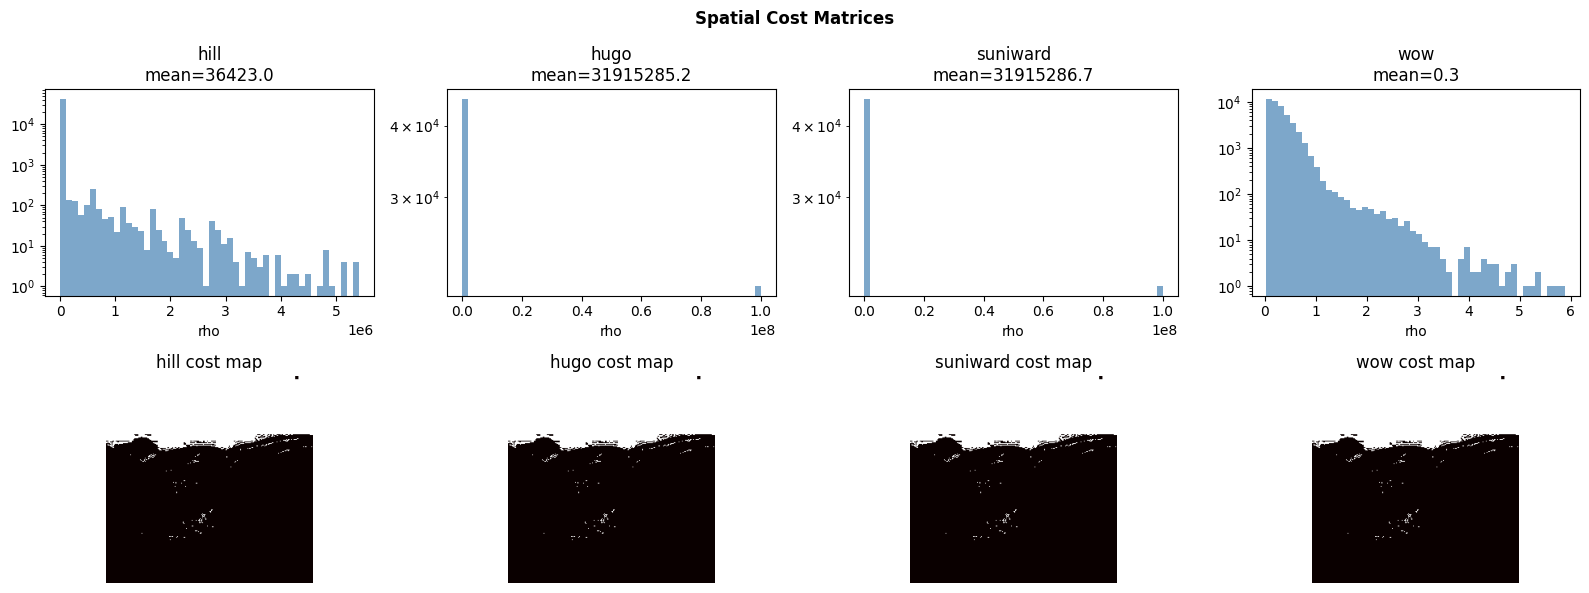

In [36]:
import conseal as cl
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

cover = load_img("1", 0.5, "cover")

cost_functions_spatial = {
    "hill": cl.hill.compute_cost_adjusted,
    "hugo": cl.hugo.compute_cost_adjusted,
    "suniward": cl.suniward.compute_cost_adjusted,
    "wow": cl.wow.compute_cost_adjusted,
}

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for i, (name, cost_fn) in enumerate(cost_functions_spatial.items()):
    rho = np.asarray(cost_fn(cover), dtype=np.float64)[0]
    rho_clipped = np.clip(
        rho, 0, np.percentile(rho, 95)
    )  # Ausreißer abschneiden

    # Histogramm
    axes[0, i].hist(
        rho.ravel()[rho.ravel() < 1e9], bins=50, color="steelblue", alpha=0.7
    )
    axes[0, i].set_title(f"{name}\nmean={rho[rho < 1e9].mean():.1f}")
    axes[0, i].set_xlabel("rho")
    axes[0, i].set_yscale("log")

    # Heatmap
    axes[1, i].imshow(rho_clipped, cmap="hot")
    axes[1, i].set_title(f"{name} cost map")
    axes[1, i].axis("off")

    rho_valid = rho.ravel()
    rho_valid = rho_valid[rho_valid < 1e9]
    print(
        f"{name}: std={rho_valid.std():.1f}, min={rho_valid.min():.1f}, max={rho_valid.max():.1f}"
    )

plt.suptitle("Spatial Cost Matrices", fontweight="bold")
plt.tight_layout()
plt.savefig("cost_matrices_spatial.png", dpi=200)
plt.show()

juniward: std=189.5, min=13.7, max=3872.2
uerd: std=0.0, min=0.0, max=0.3
ebs: std=92.1, min=3.7, max=1089.6


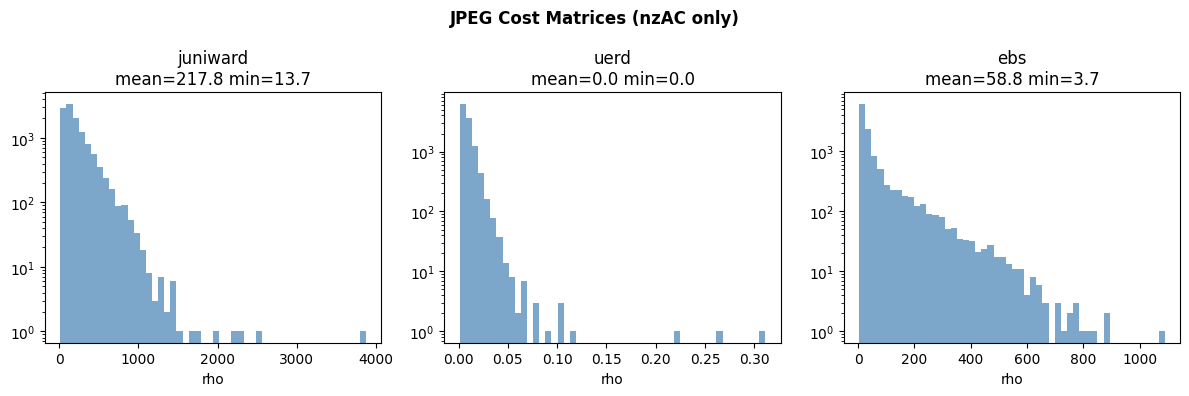

In [35]:
cover_dct, cover_spatial, qtable = load_jpeg("1", "50", "cover")

embed_mask = cover_dct != 0
embed_mask[:, :, 0, 0] = False

cost_functions_jpeg = {
    "juniward": lambda: cl.juniward.compute_cost_adjusted(
        x0=cover_spatial, y0=cover_dct, qt=qtable
    ),
    "uerd": lambda: cl.uerd.compute_cost_adjusted(y0=cover_dct, qt=qtable),
    "ebs": lambda: cl.ebs.compute_cost_adjusted(y0=cover_dct, qt=qtable),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, (name, cost_fn) in enumerate(cost_functions_jpeg.items()):
    rho_raw = np.asarray(cost_fn(), dtype=np.float64)
    rho = rho_raw[0] if rho_raw.ndim == 5 else rho_raw
    rho_fit = rho[embed_mask]

    axes[i].hist(rho_fit[rho_fit < 1e9], bins=50, color="steelblue", alpha=0.7)
    axes[i].set_title(
        f"{name}\nmean={rho_fit[rho_fit < 1e9].mean():.1f} min={rho_fit[rho_fit < 1e9].min():.1f}"
    )
    axes[i].set_xlabel("rho")
    axes[i].set_yscale("log")
    rho_valid = rho_fit[(rho_fit < 1e9)]
    print(
        f"{name}: std={rho_valid.std():.1f}, min={rho_valid.min():.1f}, max={rho_valid.max():.1f}"
    )
plt.suptitle("JPEG Cost Matrices (nzAC only)", fontweight="bold")
plt.tight_layout()
plt.savefig("cost_matrices_jpeg.png", dpi=200)
plt.show()